# Dub Techno Sound Palette Research

Started: 2026-05-17

## Feature Hypothesis

### Idea

Increase the number of sound types and available sound sources in Vibe-to-MIDI while keeping the app clearly inside a Dub Techno production vocabulary.

### Target user

- Android-first electronic music producer
- Beginner or intermediate DAW user who needs help choosing instruments and sound sources
- Wants Dub Techno-ready track setup guidance, not generic synth preset browsing

### Problem

The current app exposes four playable preview layers: kick, bass, noise, and melody/stab. The data model includes broader roles such as pad, arp, pluck, and drum, but the audio engine and MIDI/Synth UI do not yet give users enough concrete sound choices per layer. Expanding sound variety without guardrails could drift into generic techno, ambient, or preset-list behavior.

### MVP scope

- Define a Dub Techno sound palette taxonomy.
- Add sound variants inside existing layers before adding many new playback toggles.
- Recommend concrete sound sources per sound type: oscillator, noise, filtered sample-like texture, delay/reverb treatment.
- Keep MIDI/Synth UI actionable: DAW target, source, FX chain, and parameter ranges.

### Non-goals

- Artist-specific emulation
- Bundled copyrighted samples, loops, stems, or presets
- A large preset browser
- Leaving Dub Techno for general EDM/techno sound packs
- Adding every sound type as a new mixer toggle in the first slice

### Research questions

1. Which sound types are core enough to Dub Techno to add first?
2. Which sound sources should each sound type use?
3. Should the first implementation extend the audio engine, the data model, or only the Synth tab?
4. How can the app increase variety without becoming a generic preset list?


## Source Notes

- https://www.ableton.com/en/blog/designing-dub-chords-in-ableton-live-with-el-chooppizza-hotline/ — Ableton describes Dub Techno chords as enriched by reverb, delay, and echo; also notes authentic sound can be made in-the-box.
- https://www.ableton.com/fr/blog/make-dub-techno-chords-operator-and-lives-effects/ — Ableton frames Dub Techno chords as evolving stabs with rhythmic echoes using Operator, Sampler, and Live effects.
- https://tracklist.live/discover/guide/dub-techno — Genre guide summarizes muted sustained chord stabs/pads, long delay/reverb, warm sub-bass, soft kick/snare programming, low-pass filtering, and resonant modulation.
- https://www.audiotent.com/blogs/production-tips/dub-techno-chord-sound-design — Production article emphasizes spring reverb, 24 dB low-pass filtering, lo-fi/noise texture, and delay for Dub Techno stabs.
- https://polarity.me/bitwig-classic-sounddesign/012-dub-chord/ — Recent Bitwig tutorial frames a classic Dub Techno chord as a simple minor chord with heavy filtered delay and reverb.
- https://www.studiobrootle.com/dub-techno-tips/ — Studio Brootle highlights chord devices, delay/reverb chains, modulation, and moving/floating hat treatment.
- https://www.ableton.com/en/packs/analog/ — Ableton Analog provides sine, square, saw, white noise, sub oscillator, filters, and modulation; useful as a stock-subtractive synth reference.
- https://www.ableton.com/en/live-manual/11/live-instrument-reference/ — Ableton Live manual describes Drift as oscillator, noise generator, dynamic filter, envelopes, and modulation sections; useful for mapping source types to common DAW synth parts.
- https://www.musicradar.com/music-tech/5-creative-ways-to-use-distortion-in-ableton-live-from-punchier-drums-to-dub-techno-delays — MusicRadar describes distortion on chord stabs to create Dub Techno-style delay and mentions filtered/noise-like character effects.
- https://www.reddit.com/r/TechnoProduction/comments/1n890if — Producer discussion emphasizes space, reverb/delay, stereo image, layering, sampling, unusual sound sources, and noise floors for Dub Techno/ambient techno context.


## Data / Analysis


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

feature_dir = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path('research/features/2026-05-17_dub-techno-sound-palette')
figures_dir = feature_dir / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

sound_types = pd.DataFrame([
    {
        'sound_type': 'kick',
        'dub_fit': 5,
        'current_support': 5,
        'implementation_cost': 1,
        'recommended_sources': 'sine pitch drop; filtered 808/909-like synth kick; soft saturated transient',
        'first_action': 'Add kick variants, not a new layer.',
    },
    {
        'sound_type': 'sub bass',
        'dub_fit': 5,
        'current_support': 5,
        'implementation_cost': 2,
        'recommended_sources': 'saw sub; triangle octave blend; sine sub; filtered square pulse',
        'first_action': 'Add bass source variants and filter profiles.',
    },
    {
        'sound_type': 'chord stab',
        'dub_fit': 5,
        'current_support': 5,
        'implementation_cost': 2,
        'recommended_sources': 'saw chord; square/saw mix; sampled chord; minor7/minor9 voicing; lowpass + delay',
        'first_action': 'Add chord source variants and echo color variants.',
    },
    {
        'sound_type': 'noise / hats',
        'dub_fit': 4,
        'current_support': 4,
        'implementation_cost': 2,
        'recommended_sources': 'filtered noise; short closed hat; vinyl/tape floor; bandpass tick',
        'first_action': 'Split noise tone variants while keeping one noise layer.',
    },
    {
        'sound_type': 'texture / room bed',
        'dub_fit': 4,
        'current_support': 1,
        'implementation_cost': 3,
        'recommended_sources': 'low-level filtered noise floor; reverb tail bed; tape hiss; distant room wash',
        'first_action': 'Add as optional sound type after variants exist.',
    },
    {
        'sound_type': 'delay return / echo send',
        'dub_fit': 5,
        'current_support': 3,
        'implementation_cost': 3,
        'recommended_sources': 'feedback repeats; filtered echo; saturated delay return; spring/plate reverb send',
        'first_action': 'Represent as FX profile first, not a playable note layer.',
    },
    {
        'sound_type': 'dub chord pad',
        'dub_fit': 4,
        'current_support': 2,
        'implementation_cost': 3,
        'recommended_sources': 'held filtered chord; reverb-frozen stab; soft detuned saw pad',
        'first_action': 'Defer until chord/stab variants are stable.',
    },
    {
        'sound_type': 'incidental ticks / clicks',
        'dub_fit': 3,
        'current_support': 1,
        'implementation_cost': 3,
        'recommended_sources': 'filtered click; rim-like tick; delay click; granular noise',
        'first_action': 'Defer; easy to overfill sparse loops.',
    },
])

sound_types['priority_score'] = sound_types['dub_fit'] + sound_types['current_support'] - sound_types['implementation_cost']
sound_types.sort_values('priority_score', ascending=False)


,sound_type,dub_fit,current_support,implementation_cost,recommended_sources,first_action,priority_score
0,kick,5,5,1,sine pitch drop; filtered 808/909-like synth k...,"Add kick variants, not a new layer.",9
1,sub bass,5,5,2,saw sub; triangle octave blend; sine sub; filt...,Add bass source variants and filter profiles.,8
2,chord stab,5,5,2,saw chord; square/saw mix; sampled chord; mino...,Add chord source variants and echo color varia...,8
3,noise / hats,4,4,2,filtered noise; short closed hat; vinyl/tape f...,Split noise tone variants while keeping one no...,6
5,delay return / echo send,5,3,3,feedback repeats; filtered echo; saturated del...,"Represent as FX profile first, not a playable ...",5
6,dub chord pad,4,2,3,held filtered chord; reverb-frozen stab; soft ...,Defer until chord/stab variants are stable.,3
4,texture / room bed,4,1,3,low-level filtered noise floor; reverb tail be...,Add as optional sound type after variants exist.,2
7,incidental ticks / clicks,3,1,3,filtered click; rim-like tick; delay click; gr...,Defer; easy to overfill sparse loops.,1


PosixPath('/Users/asami/develop/art/Vibe-to-MIDI/research/features/2026-05-17_dub-techno-sound-palette/figures/sound_expansion_priority.png')

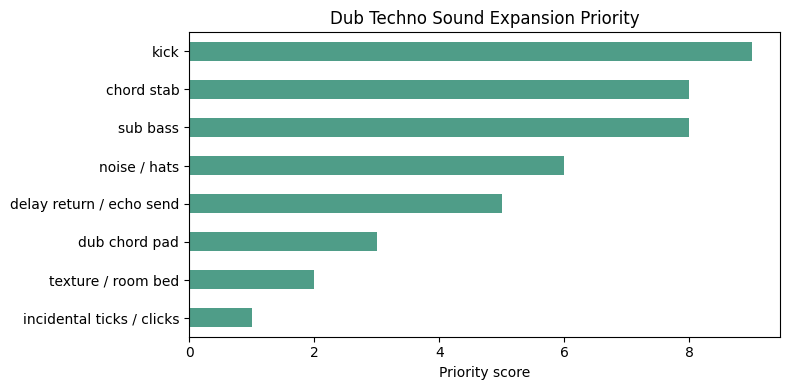

In [2]:
ax = sound_types.sort_values('priority_score').plot.barh(
    x='sound_type',
    y='priority_score',
    legend=False,
    color='#4f9d88',
    figsize=(8, 4),
)
ax.set_title('Dub Techno Sound Expansion Priority')
ax.set_xlabel('Priority score')
ax.set_ylabel('')
plt.tight_layout()
chart_path = figures_dir / 'sound_expansion_priority.png'
plt.savefig(chart_path, dpi=160)
chart_path


![Sound expansion priority](../figures/sound_expansion_priority.png)


In [3]:
implementation_options = pd.DataFrame([
    {
        'option': 'Add variants inside existing layers',
        'product_value': 5,
        'implementation_cost': 2,
        'risk': 2,
        'notes': 'Best first slice: preserve four-layer UI while increasing sound choice.',
    },
    {
        'option': 'Add new playable layers immediately',
        'product_value': 4,
        'implementation_cost': 4,
        'risk': 4,
        'notes': 'May complicate player, toggles, MIDI screen, and mobile UI too early.',
    },
    {
        'option': 'Only expand text descriptors',
        'product_value': 2,
        'implementation_cost': 1,
        'risk': 2,
        'notes': 'Cheap but does not make the audible result richer.',
    },
    {
        'option': 'Add sample packs / bundled loops',
        'product_value': 3,
        'implementation_cost': 5,
        'risk': 5,
        'notes': 'Licensing and app-size risk; conflicts with generated synthesis preference.',
    },
])

implementation_options['score'] = implementation_options['product_value'] - implementation_options['implementation_cost'] - implementation_options['risk']
implementation_options.sort_values('score', ascending=False)


,option,product_value,implementation_cost,risk,notes,score
0,Add variants inside existing layers,5,2,2,Best first slice: preserve four-layer UI while...,1
2,Only expand text descriptors,2,1,2,Cheap but does not make the audible result ric...,-1
1,Add new playable layers immediately,4,4,4,"May complicate player, toggles, MIDI screen, a...",-4
3,Add sample packs / bundled loops,3,5,5,Licensing and app-size risk; conflicts with ge...,-7


## Decision Summary

### Recommendation: Build, but narrow

Increase sound variety by adding **sound variants inside the existing four playable layers** before adding new mixer/toggle layers. Keep the Dub Techno sound world centered on kick, sub bass, chord stab, noise/hat, and echo/space.

### Evidence

- Sources consistently identify Dub Techno through chord stabs/pads, filtered echo/reverb, warm sub-bass, restrained drums, noise/lo-fi texture, and slow modulation.
- Current implementation already has the right core layers: `kick`, `bass`, `noise`, and `melody`/stab. The gap is not missing every layer; it is lack of selectable source/variant detail per layer.
- Adding many new playable layers would expand UI, audio scheduling, player toggles, MIDI screen, and tests at once. Variants are lower risk and preserve the minimal mobile workflow.
- Bundled samples or loops would create licensing and app-size risks. Generated synthesis and parameterized variants better match repo policy.

### MVP recommendation

Implement a `soundProfile` or `soundVariant` model for existing layers:

1. `kickVariant`: `deep-sine`, `soft-909`, `muffled-room`, `saturated-thump`.
2. `bassVariant`: `saw-sub`, `sine-sub`, `triangle-round`, `filtered-pulse`.
3. `stabVariant`: `saw-minor`, `square-saw`, `sampled-chord-like`, `wide-detuned`.
4. `noiseVariant`: `tape-hiss`, `closed-hat`, `vinyl-floor`, `bandpass-tick`.
5. `spaceVariant`: `short-dub`, `deep-feedback`, `spring-style`, `dark-plate` as FX profile metadata first.

Each variant should include:

- DAW target
- source oscillator/noise/sample-like description
- filter type and range
- envelope hint
- delay/reverb role where relevant
- whether it is audible in preview now or only DAW guidance

### First implementation slice

Start with data and UI, then audio:

1. Add a typed sound palette in `app/frontend/src/features/vibe-map/sound-palette.ts`.
2. Assign variants to existing VibeIds in `data.ts` without changing track count.
3. Update Synth tab Track setup to show variant names and concrete source choices.
4. Update the audio engine for the highest-value variants only: bass and stab first, then noise, then kick.
5. Keep layer toggles unchanged for MVP.

### Risks

- Too many variant names can become a preset browser instead of DAW guidance.
- Variants shown in Synth tab must match the preview sound, or user trust drops.
- Extra layers can crowd the mobile player bar and MIDI screen.
- Sound sources must remain generated or clearly redistributable; avoid sample-pack dependencies.
- Dub Techno boundary can blur if adding leads, bright arps, risers, and generic FX too early.

### Next step

Build a typed sound-palette layer with 4-5 variants per existing layer and expose those variants in the Synth tab. Do not add new player toggles in the first implementation.

### Notebook execution status

Executed successfully with `research/.venv/bin/jupyter nbconvert --to notebook --execute` on 2026-05-17. Generated `figures/sound_expansion_priority.png`.


## Open Questions

- Should sound variants be assigned per `VibeId` manually, or derived from existing filters and descriptors?
- Should preview audio implement all variants immediately or mark some as DAW guidance only?
- How should `spaceVariant` appear in UI if it is FX metadata rather than a MIDI/audio layer?
- Should `melody` be renamed to `stab` internally, or only in UI, before sound variants expand?
- What is the minimum set of variants that can be tested reliably on Android native audio?
